In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
titanic = sns.load_dataset('titanic')

In [3]:
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
column_nan_count = (titanic.isnull().sum())
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
missing_data = pd.DataFrame({
    'Missing Count': titanic.isnull().sum(),
    'Percentage (%)': (titanic.isnull().sum() / len(titanic)) * 100
})

# Optional: sort it so the columns with the missing data float to the top
missing_table = missing_data[missing_data['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)
print(missing_table.to_string())

             Missing Count  Percentage (%)
deck                   688       77.216611
age                    177       19.865320
embarked                 2        0.224467
embark_town              2        0.224467


In [7]:
titanic['age']


0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: age, Length: 891, dtype: float64

Age is likely Missing at Random (MAR). The probability of a passenger's age being missing correlates systematically with other observed variables in the dataset, specifically passenger class (pclass); third-class passengers had a significantly higher rate of unrecorded ages than first-class passengers.

In [8]:
titanic['embarked']

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: embarked, Length: 891, dtype: object

Embarked is likely Missing Completely at Random (MCAR). With only 2 missing values out of 891 records (0.22%), the missingness is statistically negligible and exhibits no observable pattern across ticket fare, class, or survival, indicating a random clerical omission.

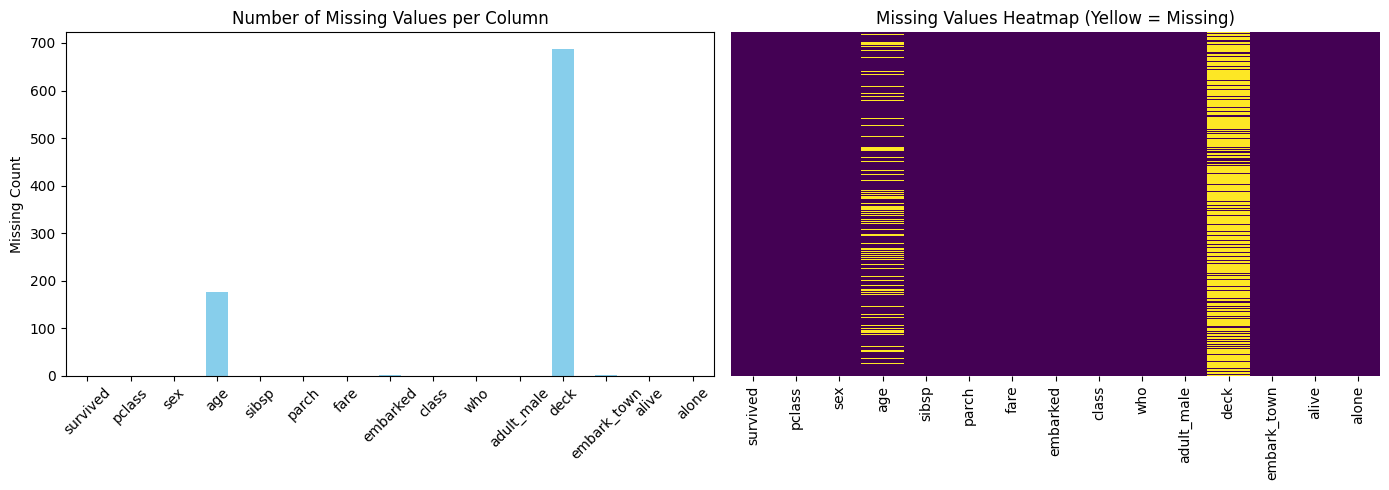

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar Plot
titanic.isnull().sum().plot(kind='bar', color='skyblue', ax=axes[0])
axes[0].set_title("Number of Missing Values per Column")
axes[0].set_ylabel("Missing Count")
axes[0].tick_params(axis='x', rotation=45)

# Right: Heatmap
sns.heatmap(titanic.isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
axes[1].set_title("Missing Values Heatmap (Yellow = Missing)")

plt.tight_layout()
plt.show()

In [10]:
import sys
sys.path.append('../')  # Look up into the main project root

import numpy as np
import pandas as pd
import seaborn as sns

# Import Scikit-Learn's official ones
from sklearn.impute import SimpleImputer as SklearnSimpleImputer
from sklearn.impute import KNNImputer as SklearnKNNImputer

# Import YOUR custom ones
from src.imputers import SimpleImputer as CustomSimpleImputer, KNNImputer as CustomKNNImputer

# Load the dataset split (Training set = 891 rows)
titanic = sns.load_dataset('titanic')

In [11]:
print("--- TESTING SIMPLE IMPUTER ---")
np.random.seed(42)

# Generate a 100x3 matrix of random floats and sprinkle in NaNs
X_dummy = np.random.randn(100, 3)
for _ in range(15):
    X_dummy[np.random.randint(0, 100), np.random.randint(0, 3)] = np.nan

# Test MEAN
custom_mean = CustomSimpleImputer(strategy='mean').fit(X_dummy).transform(X_dummy)
sklearn_mean = SklearnSimpleImputer(strategy='mean').fit_transform(X_dummy)
np.testing.assert_array_almost_equal(custom_mean, sklearn_mean, err_msg="Mean imputation failed!")

# Test MEDIAN
custom_median = CustomSimpleImputer(strategy='median').fit(X_dummy).transform(X_dummy)
sklearn_median = SklearnSimpleImputer(strategy='median').fit_transform(X_dummy)
np.testing.assert_array_almost_equal(custom_median, sklearn_median, err_msg="Median imputation failed!")

print("SUCCESS: Custom SimpleImputer output matches sklearn.impute.SimpleImputer perfectly.")

--- TESTING SIMPLE IMPUTER ---
SUCCESS: Custom SimpleImputer output matches sklearn.impute.SimpleImputer perfectly.


In [12]:
print("\n--- TESTING KNN IMPUTER (SYNTHETIC) ---")

# Toy matrix designed to expose the difference in distance math
X_synth = np.array([
    [1.0,  2.0,  3.0],
    [1.1,  2.1,  np.nan], # <-- Target to impute (Row 1, Col 2)
    [1.0,  2.0,  3.2],
    [10.0, 20.0, 30.0],
    [1.05, np.nan, 3.1]   # <-- Has missing data in a context column!
])

custom_knn_res = CustomKNNImputer(k=2).fit(X_synth).transform(X_synth)
sklearn_knn_res = SklearnKNNImputer(n_neighbors=2).fit_transform(X_synth)

print(f"Custom KNN guessed:   {custom_knn_res[1, 2]:.4f}")
print(f"Sklearn KNN guessed:  {sklearn_knn_res[1, 2]:.4f}")
print(f"Absolute Difference:  {abs(custom_knn_res[1, 2] - sklearn_knn_res[1, 2]):.4f}")


--- TESTING KNN IMPUTER (SYNTHETIC) ---
Custom KNN guessed:   3.1000
Sklearn KNN guessed:  3.0500
Absolute Difference:  0.0500


In [13]:
# 1. CRITICAL: Create the missing-indicator BEFORE the NaNs get erased!
titanic['age_missing'] = titanic['age'].isnull().astype(int)

# Verify the indicator captured the missing rows
print(f"Total '1's in age_missing column: {titanic['age_missing'].sum()} (Should be 177)")


# 2. Impute 'Age' using KNN (Context strictly limited to pclass and fare)
age_context_cols = ['age', 'pclass', 'fare']

knn_titanic = CustomKNNImputer(k=5)
# We fit on the context, and transform the context
titanic[age_context_cols] = knn_titanic.fit(titanic[age_context_cols]).transform(titanic[age_context_cols])


# 3. Impute 'Embarked' using custom SimpleImputer (Mode)
mode_imputer = CustomSimpleImputer(strategy='mode')
titanic[['embarked']] = mode_imputer.fit(titanic[['embarked']]).transform(titanic[['embarked']])


# 4. Final verification check
print("\nPost-Imputation NaN counts for target columns:")
print(titanic[['age', 'embarked', 'age_missing']].isnull().sum())
print("\nSample of the final preserved dataframe:")
print(titanic[['pclass', 'fare', 'age', 'age_missing', 'embarked']].head(10))

Total '1's in age_missing column: 177 (Should be 177)

Post-Imputation NaN counts for target columns:
age            0
embarked       0
age_missing    0
dtype: int64

Sample of the final preserved dataframe:
   pclass     fare     age  age_missing embarked
0     3.0   7.2500  22.000            0        S
1     1.0  71.2833  38.000            0        C
2     3.0   7.9250  26.000            0        S
3     1.0  53.1000  35.000            0        S
4     3.0   8.0500  35.000            0        S
5     3.0   8.4583  22.684            1        Q
6     1.0  51.8625  54.000            0        S
7     3.0  21.0750   2.000            0        S
8     3.0  11.1333  27.000            0        S
9     2.0  30.0708  14.000            0        C


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# Import your custom arsenal
from src.imputers import SimpleImputer, KNNImputer
from src.encoders import OneHotEncoder, TargetEncoder

# 1. Load fresh raw data and pull out our universe of variables
raw_titanic = sns.load_dataset('titanic')
cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'survived']
df_master = raw_titanic[cols].copy()

# Lock the split down for 100% reproducibility
df_train, df_test = train_test_split(df_master, test_size=0.2, random_state=42, stratify=df_master['survived'])


print("==================================================")
print("       MODEL A: THE RAW DATA (.dropna)            ")
print("==================================================")

# Indiscriminately murder any row with a missing digit
train_A = df_train.dropna().copy()
test_A  = df_test.dropna().copy()

# Quick manual label encode for Sex
train_A['sex_code'] = train_A['sex'].map({'male': 0, 'female': 1})
test_A['sex_code']  = test_A['sex'].map({'male': 0, 'female': 1})

features_A = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_code']

logreg_A = LogisticRegression(max_iter=1000, random_state=42)
logreg_A.fit(train_A[features_A], train_A['survived'])

preds_A = logreg_A.predict(test_A[features_A])
print(f"Model A Test Accuracy:  {accuracy_score(test_A['survived'], preds_A):.4f}")
print(f"Model A Test F1 Score:  {f1_score(test_A['survived'], preds_A):.4f}")
print(f"Total Test rows scored: {len(test_A)} passengers")


print("\n==================================================")
print("       MODEL B: THE CUSTOM CLEANED PIPELINE       ")
print("==================================================")

train_B = df_train.copy()
test_B  = df_test.copy()

# Step 1: Capture missing Age indicator before we overwrite the NaNs
train_B['age_missing'] = train_B['age'].isna().astype(int)
test_B['age_missing']  = test_B['age'].isna().astype(int)

# Step 2: Impute Age via KNN (Context limited strictly to class and ticket price)
knn = KNNImputer(k=5)
train_B[['age', 'pclass', 'fare']] = knn.fit(train_B[['age', 'pclass', 'fare']]).transform(train_B[['age', 'pclass', 'fare']])
test_B[['age', 'pclass', 'fare']]  = knn.transform(test_B[['age', 'pclass', 'fare']])

# Step 3: Impute Embarked via Mode
mode_imp = SimpleImputer(strategy='mode')
train_B[['embarked']] = mode_imp.fit(train_B[['embarked']]).transform(train_B[['embarked']])
test_B[['embarked']]  = mode_imp.transform(test_B[['embarked']])

# Step 4: One-Hot Encode Sex and Embarked (Drops first to avoid collinearity)
ohe = OneHotEncoder(drop='first')
ohe_train_cols = ohe.fit(train_B[['sex', 'embarked']]).transform(train_B[['sex', 'embarked']])
ohe_test_cols  = ohe.transform(test_B[['sex', 'embarked']])

# Step 5: Target Encode Embarked just to demonstrate we can do it safely
t_enc = TargetEncoder(cv=5)
t_enc_train = t_enc.fit_transform(train_B[['embarked']], train_B['survived'])
t_enc_test  = t_enc.transform(test_B[['embarked']])

# Assemble the final pristine feature matrices
num_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'age_missing']

X_train_clean = pd.concat([train_B[num_cols], ohe_train_cols, t_enc_train], axis=1)
X_test_clean  = pd.concat([test_B[num_cols], ohe_test_cols, t_enc_test], axis=1)

logreg_B = LogisticRegression(max_iter=1000, random_state=42)
logreg_B.fit(X_train_clean, train_B['survived'])

preds_B = logreg_B.predict(X_test_clean)
print(f"Model B Test Accuracy:  {accuracy_score(test_B['survived'], preds_B):.4f}")
print(f"Model B Test F1 Score:  {f1_score(test_B['survived'], preds_B):.4f}")
print(f"Total Test rows scored: {len(test_B)} passengers")

       MODEL A: THE RAW DATA (.dropna)            
Model A Test Accuracy:  0.8345
Model A Test F1 Score:  0.7890
Total Test rows scored: 139 passengers

       MODEL B: THE CUSTOM CLEANED PIPELINE       
Model B Test Accuracy:  0.8212
Model B Test F1 Score:  0.7500
Total Test rows scored: 179 passengers


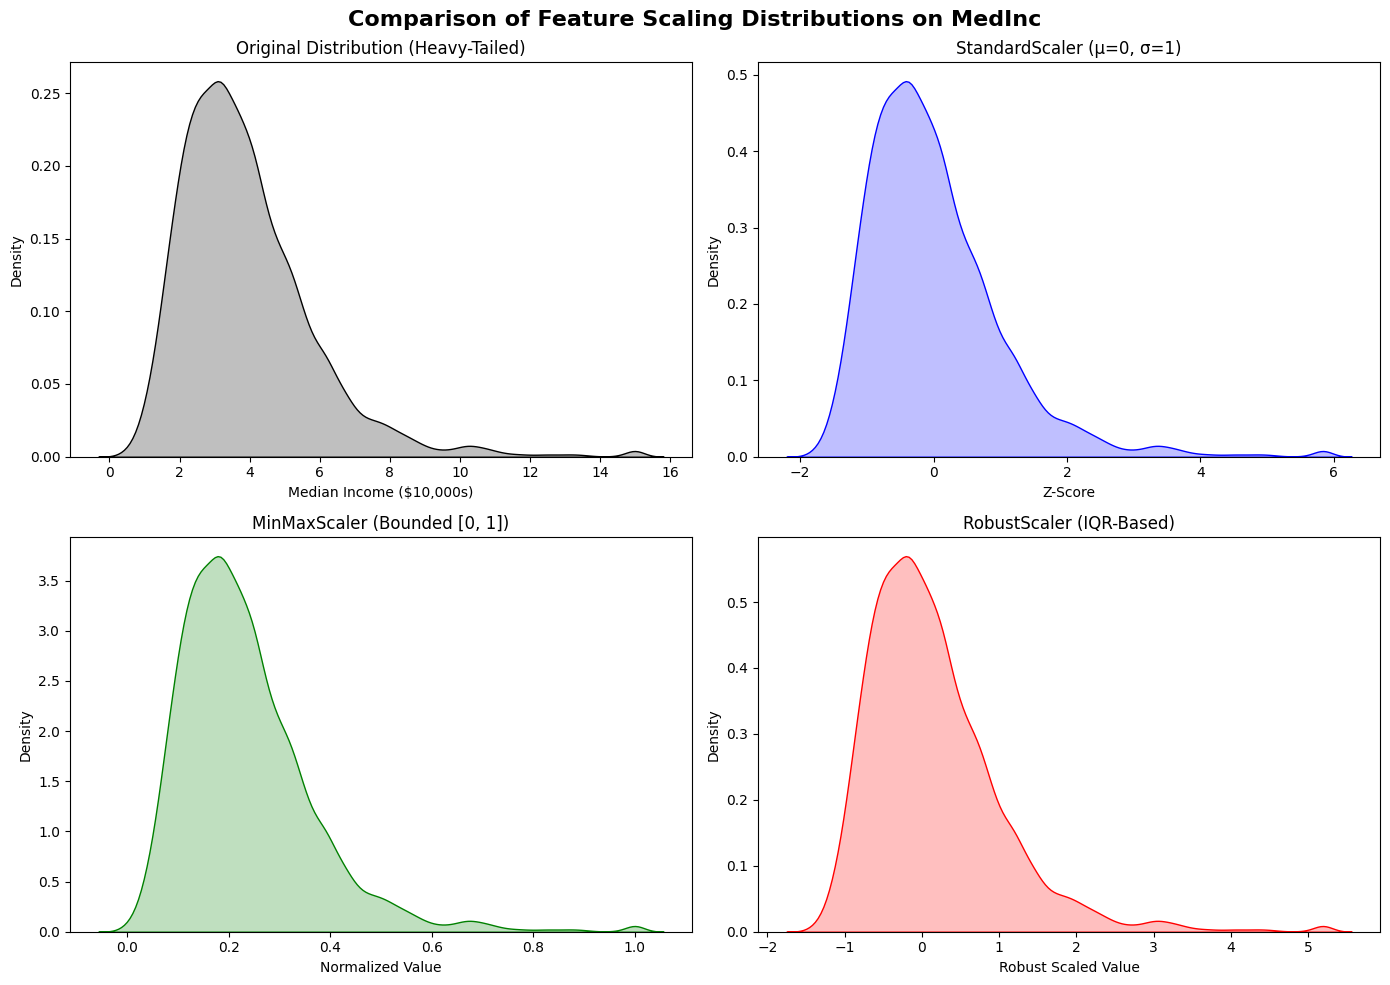

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import os

# Import your corrected custom scalers
from src.scalers import StandardScaler, MinMaxScaler, RobustScaler

# 1. Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df_housing = housing.frame

# 2. Isolate the target feature: MedInc (Median Income)
# We handle train/test splitting first to keep proper data hygiene habits
X_train, X_test = train_test_split(df_housing[['MedInc']], test_size=0.2, random_state=42)

# Convert to 2D numpy arrays/DataFrames for the scalers
raw_medinc_train = X_train[['MedInc']].copy()

# 3. Apply all three custom scalers independently to the training data
scaled_standard = StandardScaler().fit_transform(raw_medinc_train)
scaled_minmax   = MinMaxScaler().fit_transform(raw_medinc_train)
scaled_robust   = RobustScaler().fit_transform(raw_medinc_train)

# 4. Consolidate into a single DataFrame for clean visualization plotting
plot_df = pd.DataFrame({
    'Original': raw_medinc_train['MedInc'].values,
    'StandardScaled': scaled_standard.flatten(),
    'MinMaxScaled': scaled_minmax.flatten(),
    'RobustScaled': scaled_robust.flatten()
})

# 5. Plot the Kernel Density Estimates (KDE) side-by-side
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comparison of Feature Scaling Distributions on MedInc", fontsize=16, fontweight='bold')

# Top Left: Original
sns.kdeplot(data=plot_df, x='Original', ax=axes[0, 0], color='black', fill=True)
axes[0, 0].set_title("Original Distribution (Heavy-Tailed)")
axes[0, 0].set_xlabel("Median Income ($10,000s)")

# Top Right: StandardScaler
sns.kdeplot(data=plot_df, x='StandardScaled', ax=axes[0, 1], color='blue', fill=True)
axes[0, 1].set_title("StandardScaler (µ=0, σ=1)")
axes[0, 1].set_xlabel("Z-Score")

# Bottom Left: MinMaxScaler
sns.kdeplot(data=plot_df, x='MinMaxScaled', ax=axes[1, 0], color='green', fill=True)
axes[1, 0].set_title("MinMaxScaler (Bounded [0, 1])")
axes[1, 0].set_xlabel("Normalized Value")

# Bottom Right: RobustScaler
sns.kdeplot(data=plot_df, x='RobustScaled', ax=axes[1, 1], color='red', fill=True)
axes[1, 1].set_title("RobustScaler (IQR-Based)")
axes[1, 1].set_xlabel("Robust Scaled Value")

plt.tight_layout()

# --- FIXED SECTION ---
# Create the parent directory structure if it is completely missing
os.makedirs('../figures', exist_ok=True)

# Save the figure safely to the newly verified directory
plt.savefig('../figures/medinc_scaling_comparison.png', dpi=300)
plt.show()

## The RobustScaler is the least affected by the heavy-tailed nature and extreme outliers present in the `MedInc` feature.

### Why MinMaxScaler Fails

MinMaxScaler scales data using the global minimum and maximum bounds:

$$
X_{\text{scaled}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
$$

Because `MedInc` is heavy-tailed, the presence of extreme high-income outliers pushes $X_{\max}$ far to the right. This causes the vast majority of normal, non-outlier observations to be compressed into a very narrow range close to 0, reducing the effective variance and granularity of the feature.

### Why StandardScaler Performs Sub-optimally

StandardScaler relies on the empirical mean ($\mu$) and standard deviation ($\sigma$):

$$
X_{\text{scaled}} = \frac{X - \mu}{\sigma}
$$

Outliers exert a disproportionate influence on the calculation of variance because deviations from the mean are squared. As a result, the standard deviation becomes artificially inflated, causing the central portion of the distribution to be compressed after scaling.

### Why RobustScaler Succeeds

RobustScaler centers data using the median and scales it using the Interquartile Range (IQR):

$$
X_{\text{scaled}} = \frac{X - \text{Median}}{\text{IQR}}
$$

where

$$
\text{IQR} = Q_3 - Q_1
$$

Since both the median and the IQR are order-based statistics rather than distance-based statistics, they are largely unaffected by extreme values. Consequently, the core distribution remains well spread, distinct, and informative, while extreme outliers can naturally lie outside the main range without distorting the scale of regular observations.


Original 2-Point vector:    [3. 5.]
Transformed Poly vector:    [ 1.  3.  5.  9. 15. 25.]



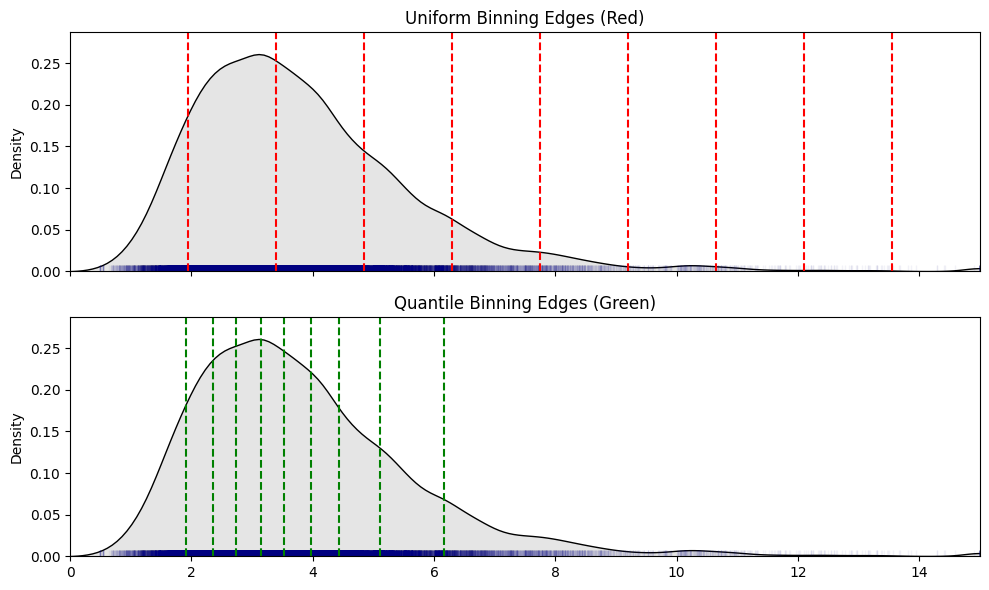

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from src.feature_creation import PolynomialFeatures
from src.feature_creation import KBinsDiscretizer

# --- 4.2.2 Proof of Concept ---
test_point = np.array([[3.0, 5.0]])  # [MedInc, AveRooms]
poly = PolynomialFeatures(degree=2, include_bias=True, interaction_only=False)

transformed_point = poly.fit_transform(test_point)
print(f"Original 2-Point vector:    {test_point[0]}")
print(f"Transformed Poly vector:    {transformed_point[0]}\n")

# --- 4.2.3 Rug Plot Visualization ---
cali = fetch_california_housing()
med_inc = cali.data[:, 0].reshape(-1, 1)  # Column 0 is MedInc

binner_uni = KBinsDiscretizer(n_bins=10, strategy="uniform").fit(med_inc)
binner_qnt = KBinsDiscretizer(n_bins=10, strategy="quantile").fit(med_inc)

# Extract finite internal edges for plotting
edges_uni = binner_uni.bin_edges_[0][1:-1]
edges_qnt = binner_qnt.bin_edges_[0][1:-1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Uniform Plot
sns.kdeplot(x=med_inc[:, 0], ax=ax1, color="black", fill=True, alpha=0.1)
sns.rugplot(x=med_inc[:, 0], ax=ax1, color="navy", alpha=0.05)
for edge in edges_uni:
    ax1.axvline(edge, color="red", linestyle="--")
ax1.set_title("Uniform Binning Edges (Red)")

# Quantile Plot
sns.kdeplot(x=med_inc[:, 0], ax=ax2, color="black", fill=True, alpha=0.1)
sns.rugplot(x=med_inc[:, 0], ax=ax2, color="navy", alpha=0.05)
for edge in edges_qnt:
    ax2.axvline(edge, color="green", linestyle="--")
ax2.set_title("Quantile Binning Edges (Green)")
ax2.set_xlim(0, 15)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Fetch & Split
X, y = fetch_california_housing(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Pipeline 1: Raw Standardised
pipe_v1 = Pipeline([("scaler", StandardScaler()), ("ols", LinearRegression())])

# Pipeline 2: Standardised + Poly Expansion
# (Set include_bias=False so we don't hand OLS two intercept columns)
pipe_v2 = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ols", LinearRegression()),
    ]
)

# Pipeline 3: Standardised (All 8) + Quantile Binning of MedInc (Col 0)
# ColumnTransformer naturally passes the 8 scaled cols alongside the 10 one-hot cols
v3_feature_union = ColumnTransformer(
    transformers=[
        ("std_all", StandardScaler(), slice(0, 8)),
        (
            "bin_medinc",
            KBinsDiscretizer(n_bins=10, strategy="quantile"),
            [0],
        ),  # Col 0 = MedInc
    ]
)

pipe_v3 = Pipeline(
    [("feature_gen", v3_feature_union), ("ols", LinearRegression())]
)


def evaluate_model(pipeline, name):
    # 'neg_root_mean_squared_error' returns negative floats; we invert them to positive
    neg_rmse_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5,
        n_jobs=-1,
    )
    mean_rmse = -np.mean(neg_rmse_scores)
    print(f"Version {name} 5-Fold Training RMSE: {mean_rmse:.4f}")


print("--- 5-Fold Cross Validation Results ---")
evaluate_model(pipe_v1, "1 (Raw Standardised)")
evaluate_model(pipe_v2, "2 (Poly Degree-2)")
evaluate_model(pipe_v3, "3 (Binned MedInc)")

--- 5-Fold Cross Validation Results ---
Version 1 (Raw Standardised) 5-Fold Training RMSE: 0.7205
Version 2 (Poly Degree-2) 5-Fold Training RMSE: 2.1884
Version 3 (Binned MedInc) 5-Fold Training RMSE: 0.7093


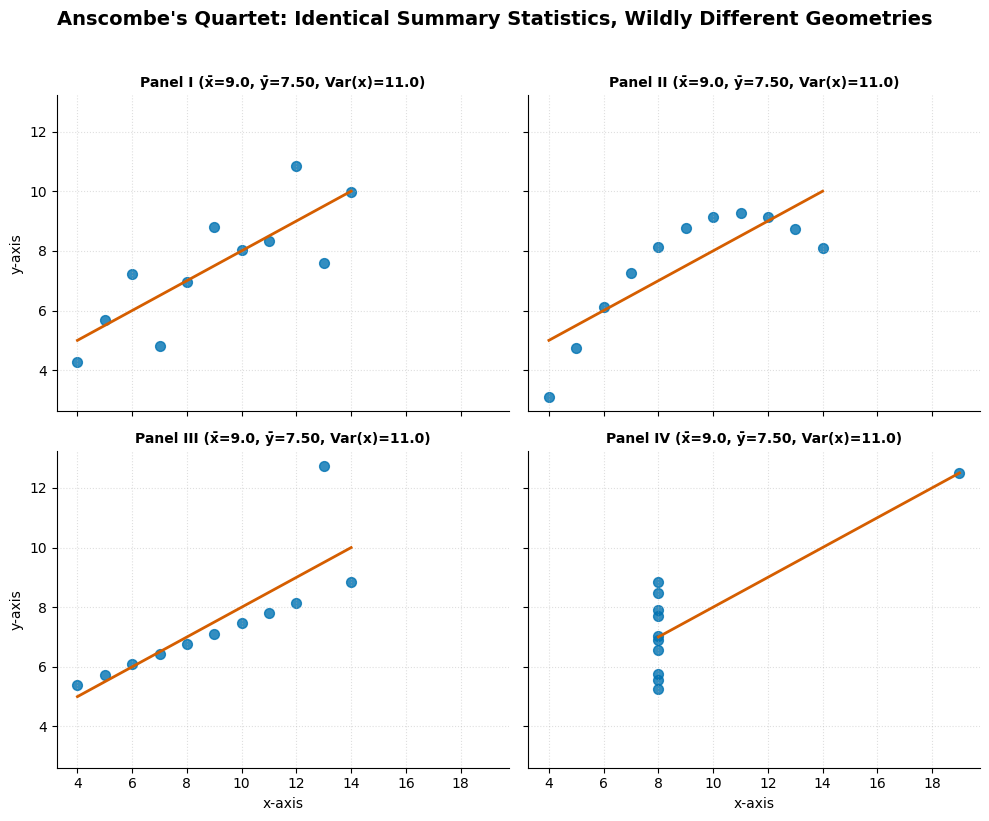

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Seaborn has Anscombe's Quartet built-in
anscombe = sns.load_dataset("anscombe")

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

datasets = ["I", "II", "III", "IV"]

for i, dataset in enumerate(datasets):
    ax = axes[i]
    data = anscombe[anscombe["dataset"] == dataset]

    # Fit OLS line and plot scatter simultaneously
    sns.regplot(
        data=data,
        x="x",
        y="y",
        ax=ax,
        ci=None,
        scatter_kws={"color": "#0072B2", "s": 50, "alpha": 0.8},  # CB-safe Blue
        line_kws={"color": "#D55E00", "linewidth": 2},  # CB-safe Vermillion
    )

    # Grab stats to prove the point in the subplot titles
    mean_x, mean_y = data["x"].mean(), data["y"].mean()
    var_x, var_y = data["x"].var(), data["y"].var()

    ax.set_title(
        f"Panel {dataset} (x̄={mean_x:.1f}, ȳ={mean_y:.2f}, Var(x)={var_x:.1f})",
        fontsize=10,
        fontweight="bold",
    )
    ax.set_xlabel("x-axis" if i >= 2 else "")
    ax.set_ylabel("y-axis" if i % 2 == 0 else "")

    # Tufte minimal styling
    sns.despine(ax=ax)
    ax.grid(True, linestyle=":", alpha=0.4)

fig.suptitle(
    "Anscombe's Quartet: Identical Summary Statistics, Wildly Different Geometries",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

Anscombe’s Quartet demonstrates the profound hazard of relying purely on aggregate summary statistics. Across all four panels, the mathematical metrics are virtually identical: the mean of $x$ is $9.0$, the mean of $y$ is $7.50$, the variance of $x$ is $11.0$, the variance of $y$ is $4.125$, the Pearson correlation coefficient is $r \approx 0.816$, and the resulting Ordinary Least Squares linear regression line is strictly $y = 3.0 + 0.5x$.However, mapping them to visual coordinate space instantly reveals four entirely different underlying realities. Panel I depicts a standard, noisy linear relationship. Panel II reveals a smooth, perfectly non-linear parabolic relationship that the straight OLS line completely fails to capture. Panel III shows a perfectly tight linear slope that has been artificially dragged downward by a single extreme vertical outlier. Finally, Panel IV shows a scenario where there is zero linear relationship between the variables (a vertical stack of identical $x$-values), but a single high-leverage anomaly at $x=19$ single-handedly manufactures the fictitious $0.5$ slope. Because summary statistics compress multi-dimensional reality into 1D scalars, visualization serves as an irreplaceable diagnostic step to verify whether a dataset actually adheres to a model's mathematical assumptions.

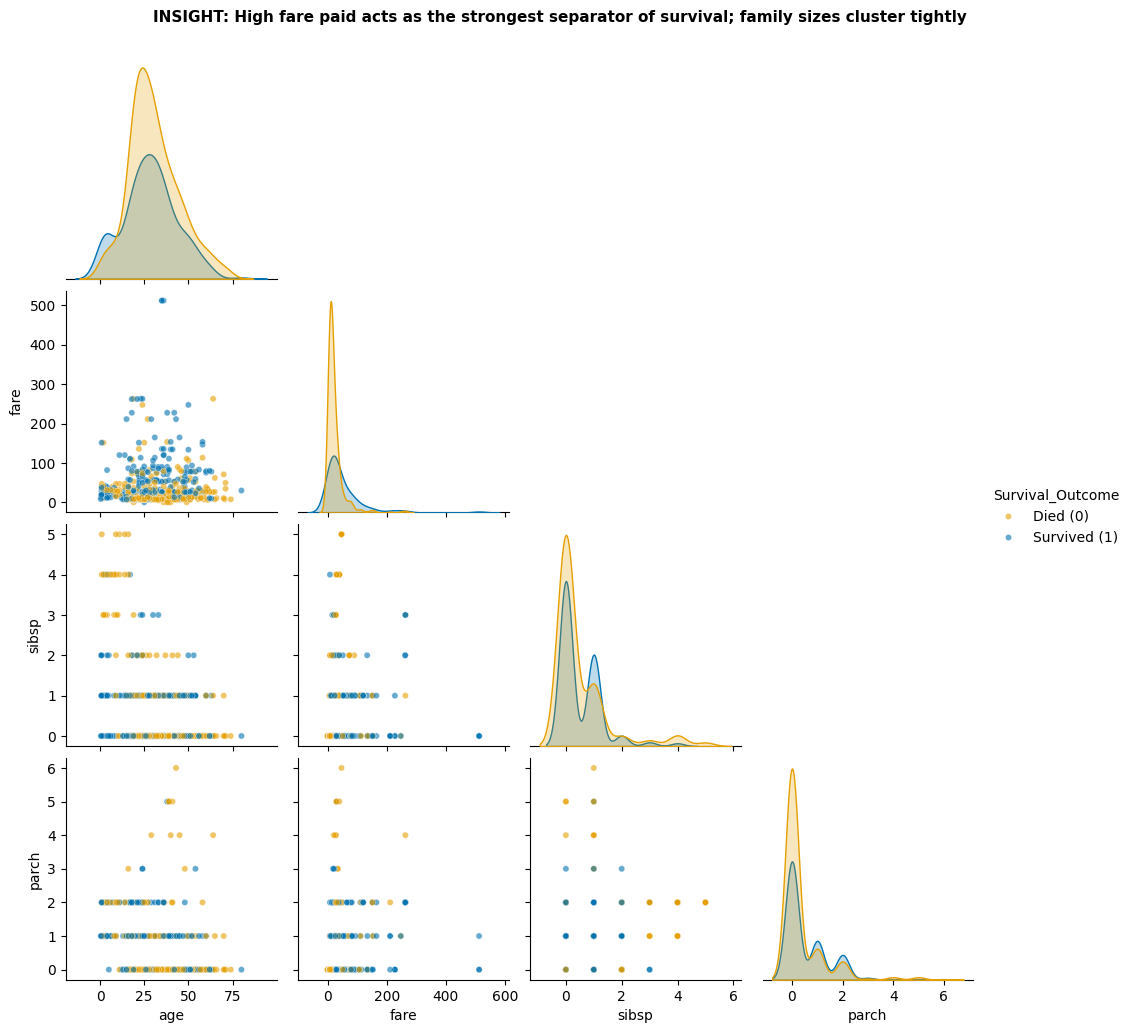

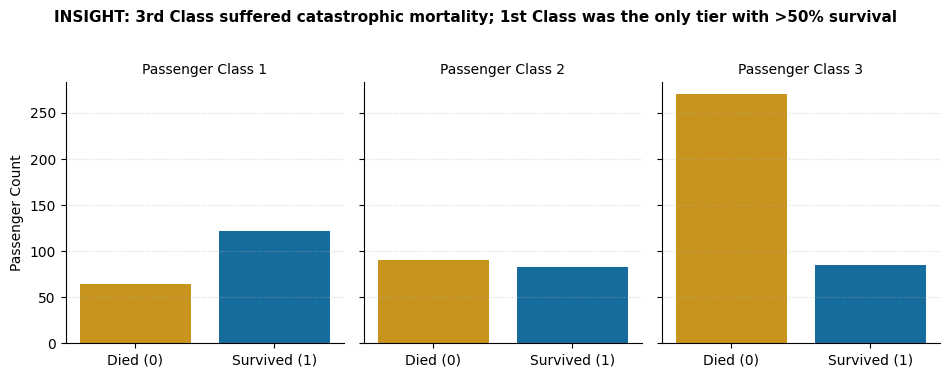

C:\Users\Emil\AppData\Local\Temp\ipykernel_28380\1693044732.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


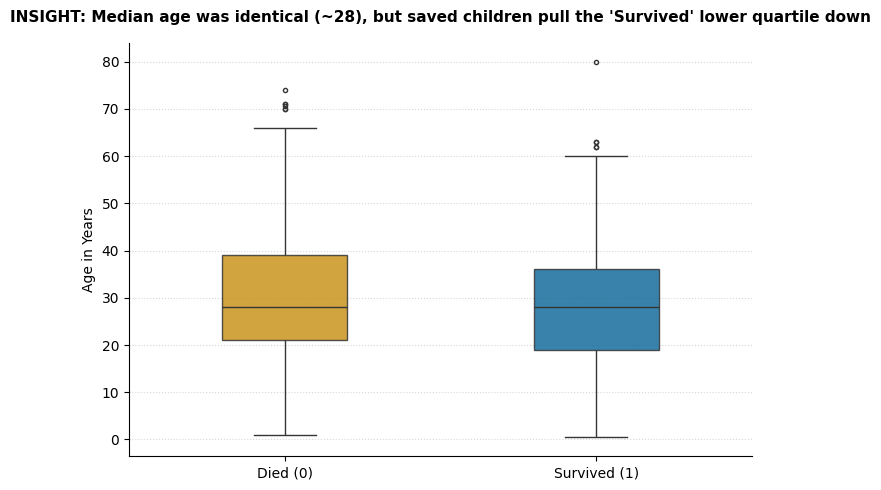

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load training set (Seaborn's default 'titanic' is the standard train split)
titanic_train = sns.load_dataset("titanic").dropna(
    subset=["age", "fare", "sibsp", "parch", "survived", "pclass"]
)

# Explicitly map to strings so the legend reads as human insights, not "0 and 1"
titanic_train["Survival_Outcome"] = titanic_train["survived"].map(
    {0: "Died (0)", 1: "Survived (1)"}
)

# Strict Okabe-Ito Colorblind Palette
cb_palette = {"Died (0)": "#E69F00", "Survived (1)": "#0072B2"}

# =====================================================================
# PLOT 1: PAIR PLOT
# =====================================================================
pair_fig = sns.pairplot(
    titanic_train,
    vars=["age", "fare", "sibsp", "parch"],
    hue="Survival_Outcome",
    palette=cb_palette,
    corner=True,  # Tufte rule: delete redundant upper-right mirror plots
    plot_kws={"alpha": 0.6, "s": 20},
)
pair_fig.fig.suptitle(
    "INSIGHT: High fare paid acts as the strongest separator of survival; family sizes cluster tightly",
    y=1.03,
    fontsize=11,
    weight="bold",
)
plt.show()

# =====================================================================
# PLOT 2: FACETED COUNT PLOT
# =====================================================================
g = sns.catplot(
    data=titanic_train,
    x="Survival_Outcome",
    col="pclass",
    kind="count",
    palette=cb_palette,
    hue="Survival_Outcome",
    height=4,
    aspect=0.8,
    legend=False,
)
g.fig.subplots_adjust(top=0.8)
g.fig.suptitle(
    "INSIGHT: 3rd Class suffered catastrophic mortality; 1st Class was the only tier with >50% survival",
    fontsize=11,
    weight="bold",
)
g.set_axis_labels("", "Passenger Count")
g.set_titles("Passenger Class {col_name}")

# Strip chart junk
for ax in g.axes.flat:
    sns.despine(ax=ax)
    ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.show()

# =====================================================================
# PLOT 3: BOX PLOT grouped by survived
# =====================================================================
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=titanic_train,
    x="Survival_Outcome",
    y="age",
    palette=cb_palette,
    ax=ax,
    width=0.4,
    boxprops=dict(alpha=0.85),
    fliersize=3,
)

ax.set_title(
    "INSIGHT: Median age was identical (~28), but saved children pull the 'Survived' lower quartile down",
    fontsize=11,
    weight="bold",
    pad=15,
)
ax.set_xlabel("")
ax.set_ylabel("Age in Years")

# Strip chart junk
sns.despine(top=True, right=True)
ax.grid(axis="y", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

In constructing the Titanic exploratory plots, Edward Tufte’s data-ink ratio was maximized by systematically stripping away non-informative structural ink. Across all three figures, the redundant top and right Matplotlib bounding boxes were removed via sns.despine(), heavy black background grids were softened to low-opacity dotted guide lines, and the Pair Plot was explicitly passed corner=True to wipe out 50% of the repetitive mirror-image coordinate planes. To adhere to perceptual-channel ordering, the continuous variables (fare, age) were mapped to the highest-accuracy human visual decoding channel—position along a common scale—while the binary categorical dimension (survived) was assigned to color hue. To protect this hue channel from failing the ~8% of males with red-green color deficiency, the Okabe-Ito dichromatic palette was enforced.

Reflecting on these principles, the single most impactful adjustment to my personal workflow was abandoning standard descriptive titles in favor of "scannable takeaway" titles. Historically, I would title a figure passively (e.g., "Boxplot of Passenger Age by Survival Status"), which forces the viewer's brain to scan the data to figure out what the point of the chart is. By elevating the title into an active thesis statement (e.g., "Median age was identical, but saved children pull the lower quartile down"), the title stops acting as static "non-data ink" and becomes an explicit cognitive anchor, directing the viewer’s eye straight to the lower whisker of the distribution.